# ICU sign flips vs. model complexity

How does the number of reference-group sign flips across the 139 ICU data subsets change as the
fitted model gets more flexible? Every sweep below uses **exactly** the subsets, covariates, and
decomposition code of `icu_139_final_models.ipynb` (the notebook behind Table 1), and varies one
knob while holding everything else at the paper's values (Appendix B.1).

| Family | Knob | Paper setting | Held fixed |
|---|---|---|---|
| XGBoost | `max_depth` (§3) | 3 | 250 trees, lr 0.05, subsample 0.9, colsample 0.9, λ = 1, hist, log-loss |
| XGBoost | `n_estimators` (§7), 10 … 10⁴ | 250 | depth 3, same as above |
| Neural net | architecture (§4, exploratory) | `(32, 16)` | ReLU, α = 1e-4, Adam, max_iter 2000, standardized inputs |
| Neural net | width at fixed depth 3 (§8) | — | same; 3 seeds per width |
| Neural net | depth at fixed width 32 (§9) | — | same; 3 seeds per depth |

§8–§9 are *nested* sweeps — each network strictly contains the previous one — so "complexity is
increasing" is not debatable, and each setting is repeated over three initialization seeds so
optimization noise is visible rather than mistaken for a trend. Linear and logistic regression
have no comparable knob and are not swept.

Flips are counted on point estimates (no bootstrap), like the "Total flips" column of Table 1.
At the paper's settings the sweeps must reproduce Table 1 — that check is printed. For XGBoost
depth, a B = 1000 bootstrap of the same grid exists from earlier work
(`nonlinear_results_ICU_depth_sweep/`) and is merged in if found.

Data: `ICU_clean.csv` (built by `construct_ICU_data.ipynb`; not redistributed).

In [1]:
import os, sys, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# --- same configuration as icu_139_final_models.ipynb -------------------------------
CONFIG = {
    "random_state": 51,          # must match the paper notebooks for identical subsets
    "high_group_value": 0,       # 0 = men (reference direction)
    "min_subset_size": 100,
    "n_random_subsamples": 50,
    "random_subsample_fracs": [0.50, 0.30],
}
Y_COL, GROUP_COL = "In-hospital_death", "female"
X_COLS = ["Age", "ICUType", "HR", "NIMAP", "Temp", "Urine"]

N_JOBS = int(os.environ.get("OBD_N_JOBS", 8))    # parallelism across subsets
RECOMPUTE = os.environ.get("OBD_RECOMPUTE", "0") == "1"   # 1 = ignore cached sweep CSVs and refit

# --- sweep grids ---------------------------------------------------------------------
XGB_DEPTHS = list(range(1, 11))                                   # §3, paper: 3
XGB_TREES  = [10, 25, 50, 100, 250, 500, 1000, 2000, 4000, 10000] # §7, paper: 250
NN_ARCHS = [(2,), (4,), (8,), (16,), (32,), (8, 4), (16, 8), (32, 16),
            (64, 32), (32, 16, 8, 4), (64, 32, 16, 8), (128, 64, 32)]   # §4, paper: (32, 16)
NN_WIDTHS = [8, 16, 32, 64, 128, 256, 512, 768]                   # §8: (w, w, w); 768 -> 1.19M params
NN_DEPTHS = [1, 2, 3, 4, 6, 8, 12, 16]                            # §9: (32,) * d
NN_SEEDS  = [0, 1, 2]                                             # §8-9: seed 0 is the paper's
PAPER_XGB_DEPTH, PAPER_XGB_TREES, PAPER_NN_ARCH = 3, 250, (32, 16)

# --- data ----------------------------------------------------------------------------
CANDIDATES = [Path("ICU_clean.csv"),
              Path("../../Kaggle_ICU_mortality/final models/ICU_clean.csv")]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, "ICU_clean.csv not found; run construct_ICU_data.ipynb first"
df_raw = pd.read_csv(DATA_PATH)
df_clean = df_raw.dropna(subset=X_COLS + [Y_COL, GROUP_COL]).copy()
print(f"loaded {DATA_PATH}: {df_raw.shape} -> {len(df_clean):,} complete rows")

OUT_DIR = Path("complexity_sweep"); OUT_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("Figures"); FIG_DIR.mkdir(exist_ok=True)

loaded ../../Kaggle_ICU_mortality/final models/ICU_clean.csv: (3429, 48) -> 3,429 complete rows


## 1. The 139 subsets

Verbatim from `icu_139_final_models.ipynb` (legacy `np.random.seed` so the 100 random
subsamples are identical).

In [2]:
def make_quartile_subsets(df, col, label_prefix):
    q = pd.qcut(df[col], q=4, labels=False, duplicates="drop")
    return [(f"{label_prefix} quartile {int(k)}", df[q == k]) for k in sorted(q.dropna().unique())]

def make_decile_subsets(df, col, label_prefix):
    d = pd.qcut(df[col], q=10, labels=False, duplicates="drop")
    return [(f"{label_prefix} decile {int(k)}", df[d == k]) for k in sorted(d.dropna().unique())]

subsets_raw = [("All Patients", df_clean)]
for t in sorted(df_clean["ICUType"].dropna().unique()):
    subsets_raw.append((f"ICUType {t}", df_clean[df_clean["ICUType"] == t]))
subsets_raw += make_decile_subsets(df_clean, "Age", "Age")
for col, pfx in [("HR", "HR"), ("NIMAP", "MAP"), ("Temp", "Temp"), ("Urine", "Urine"), ("SAPS-I", "SAPS")]:
    if col in df_clean.columns:
        subsets_raw += make_quartile_subsets(df_clean, col, pfx)
subsets_raw.append(("HR > 100",     df_clean[df_clean["HR"] > 100]))
subsets_raw.append(("MAP < 65",     df_clean[df_clean["NIMAP"] < 65]))
subsets_raw.append(("Temp > 38C",   df_clean[df_clean["Temp"] > 38]))
subsets_raw.append(("Urine > 1000", df_clean[df_clean["Urine"] > 1000]))

np.random.seed(CONFIG["random_state"])
for i in range(1, CONFIG["n_random_subsamples"] + 1):
    idx = np.random.choice(df_clean.index, size=int(0.5 * len(df_clean)), replace=False)
    subsets_raw.append((f"Random 50% #{i}", df_clean.loc[idx]))
for i in range(1, CONFIG["n_random_subsamples"] + 1):
    idx = np.random.choice(df_clean.index, size=int(0.3 * len(df_clean)), replace=False)
    subsets_raw.append((f"Random 30% #{i}", df_clean.loc[idx]))

subsets = []
for label, sub in subsets_raw:
    sub = sub.dropna(subset=X_COLS + [Y_COL, GROUP_COL]).copy()
    if len(sub) >= CONFIG["min_subset_size"]:
        subsets.append((label, sub))
print(f"{len(subsets)} subsets (n >= {CONFIG['min_subset_size']})")
assert len(subsets) == 139
N = len(subsets)

139 subsets (n >= 100)


## 2. Decomposition and model builders

`nonlinear_oaxaca` and `predict_positive_class` are the paper notebook's functions. The
builders take the paper's hyperparameters and expose only the knob being swept.

In [3]:
def predict_positive_class(model, X):
    if hasattr(model, "predict_proba"):
        p = np.asarray(model.predict_proba(X))
        if p.ndim == 2 and p.shape[1] >= 2:
            return p[:, 1].astype(float)
        return p.ravel().astype(float)
    return np.asarray(model.predict(X), dtype=float).ravel()

def nonlinear_oaxaca(df, y_col, x_cols, group_col, model_builder, high_group_value=0):
    high = df[df[group_col] == high_group_value]
    low  = df[df[group_col] != high_group_value]
    if high.empty or low.empty:
        return {k: np.nan for k in ["difference", "explained_highref", "unexplained_highref",
                                     "explained_lowref", "unexplained_lowref"]}
    Xh, yh = high[x_cols], high[y_col]
    Xl, yl = low[x_cols],  low[y_col]
    mh_model = model_builder(); mh_model.fit(Xh, yh)
    ml_model = model_builder(); ml_model.fit(Xl, yl)
    mean_h = float(yh.mean()); mean_l = float(yl.mean())
    M_l_h = float(predict_positive_class(mh_model, Xl).mean())
    M_h_l = float(predict_positive_class(ml_model, Xh).mean())
    return {
        "difference": mean_h - mean_l,
        "explained_highref":   mean_h - M_l_h,
        "unexplained_highref": M_l_h - mean_l,
        "explained_lowref":    M_h_l - mean_l,
        "unexplained_lowref":  mean_h - M_h_l,
    }

# --- builders: paper hyperparameters, one knob exposed ---------------------------
def build_xgb(max_depth=PAPER_XGB_DEPTH, n_estimators=PAPER_XGB_TREES):
    return lambda: XGBClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=0.05,
                                 subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                                 eval_metric="logloss", random_state=0, n_jobs=1,
                                 tree_method="hist", verbosity=0)

def build_nn(hidden=PAPER_NN_ARCH, seed=0):
    return lambda: Pipeline([("scaler", StandardScaler()),
                             ("clf", MLPClassifier(hidden_layer_sizes=hidden, activation="relu",
                                                   alpha=1e-4, max_iter=2000, solver="adam",
                                                   random_state=seed))])

def nn_n_params(hidden, n_in=len(X_COLS), n_out=1):
    """Trainable weights + biases of a fully connected net."""
    sizes = [n_in, *hidden, n_out]
    return int(sum(a * b + b for a, b in zip(sizes[:-1], sizes[1:])))

# --- one (setting, subset) evaluation --------------------------------------------
def evaluate(setting_label, builder, subset_label, sub):
    try:
        r = nonlinear_oaxaca(sub, Y_COL, X_COLS, GROUP_COL, builder, CONFIG["high_group_value"])
        err = ""
    except Exception as e:
        r = {k: np.nan for k in ["difference", "explained_highref", "unexplained_highref",
                                 "explained_lowref", "unexplained_lowref"]}
        err = repr(e)
    exp_flip   = bool(np.sign(r["explained_highref"])   != np.sign(r["explained_lowref"]))   if not np.isnan(r["explained_highref"])   else False
    unexp_flip = bool(np.sign(r["unexplained_highref"]) != np.sign(r["unexplained_lowref"])) if not np.isnan(r["unexplained_highref"]) else False
    return {"setting": setting_label, "subset": subset_label, "n": len(sub),
            "difference": r["difference"],
            "explained_menref": r["explained_highref"],   "explained_womenref": r["explained_lowref"],
            "unexplained_menref": r["unexplained_highref"], "unexplained_womenref": r["unexplained_lowref"],
            "explained_flip": exp_flip, "unexplained_flip": unexp_flip,
            "any_flip": exp_flip or unexp_flip, "error": err}

def run_sweep(settings, make_builder, tag):
    """settings: list of (label, knob). make_builder(knob) -> builder. One row per (setting, subset)."""
    t0 = time.time(); rows = []
    for label, knob in settings:
        builder = make_builder(knob)
        out = Parallel(n_jobs=N_JOBS, backend="loky")(
            delayed(evaluate)(label, builder, sl, sub) for sl, sub in subsets)
        rows += out
        print(f"  {tag} {label:<22} flips: any={sum(r['any_flip'] for r in out):3d} "
              f"explained={sum(r['explained_flip'] for r in out):3d} "
              f"unexplained={sum(r['unexplained_flip'] for r in out):3d}   [{time.time()-t0:5.0f}s]", flush=True)
    return pd.DataFrame(rows)

def cached_sweep(csv_name, settings, make_builder, tag):
    """run_sweep for the settings not already in the per-row CSV cache (sweeps take hours;
    plots take seconds). Cached rows are reused; only new grid points are fit."""
    path = OUT_DIR / csv_name
    if path.exists() and not RECOMPUTE:
        cached = pd.read_csv(path, keep_default_na=False)
        have = set(cached["setting"].astype(str))
        todo = [(lab, k) for lab, k in settings if lab not in have]
        print(f"  loaded cached {csv_name} ({len(cached)} rows, {len(have)} settings); "
              f"{len(todo)} new setting(s) to fit; set OBD_RECOMPUTE=1 to refit all")
        if not todo:
            return cached
        fresh = run_sweep(todo, make_builder, tag)
        order = {lab: i for i, (lab, _) in enumerate(settings)}
        out = pd.concat([cached, fresh], ignore_index=True)
        return out.iloc[out["setting"].astype(str).map(order).argsort(kind="stable")].reset_index(drop=True)
    return run_sweep(settings, make_builder, tag)

def summarize(df, knob_col):
    for c in ("any_flip", "explained_flip", "unexplained_flip"):
        df[c] = df[c].astype(str).str.lower().eq("true") if df[c].dtype == object else df[c].astype(bool)
    return (df.groupby(knob_col)
              .agg(total_flips=("any_flip", "sum"), explained_flips=("explained_flip", "sum"),
                   unexplained_flips=("unexplained_flip", "sum"), n_subsets=("subset", "size"),
                   n_errors=("error", lambda s: int((s != "").sum())))
              .reset_index())

def summarize_seeds(df, knob_col):
    """Per knob value: flip counts per seed, then mean / min / max across seeds."""
    for c in ("any_flip", "explained_flip", "unexplained_flip"):
        df[c] = df[c].astype(str).str.lower().eq("true") if df[c].dtype == object else df[c].astype(bool)
    per_seed = (df.groupby([knob_col, "seed"])
                  .agg(total=("any_flip", "sum"), explained=("explained_flip", "sum"),
                       unexplained=("unexplained_flip", "sum"), n_errors=("error", lambda s: int((s != "").sum())))
                  .reset_index())
    agg = (per_seed.groupby(knob_col)
                   .agg(total_mean=("total", "mean"), total_min=("total", "min"), total_max=("total", "max"),
                        explained_mean=("explained", "mean"), unexplained_mean=("unexplained", "mean"),
                        n_errors=("n_errors", "sum"))
                   .reset_index())
    return per_seed, agg

## 3. XGBoost: tree depth

Depth 1–10 with the paper's 250 trees and other settings. Depth 3 is the paper's model and must
reproduce Table 1's XGBoost row (62 subsets with a flip; 33 explained / 47 unexplained in
Tables 3–4).

In [4]:
xgb_df = cached_sweep("xgb_depth_sweep_rows.csv", [(f"depth {d}", d) for d in XGB_DEPTHS], lambda d: build_xgb(max_depth=d), "xgb")
xgb_df["max_depth"] = xgb_df["setting"].str.split().str[-1].astype(int)
xgb_df.to_csv(OUT_DIR / "xgb_depth_sweep_rows.csv", index=False)
xgb_summary = summarize(xgb_df, "max_depth")
xgb_summary.to_csv(OUT_DIR / "xgb_depth_sweep_summary.csv", index=False)
paper = xgb_summary[xgb_summary["max_depth"] == PAPER_XGB_DEPTH].iloc[0]
print(f"\nPaper setting (depth {PAPER_XGB_DEPTH}): total={int(paper.total_flips)} explained={int(paper.explained_flips)} "
      f"unexplained={int(paper.unexplained_flips)}   | Table 1 / Tables 3-4: 62 / 33 / 47")
xgb_summary

  loaded cached xgb_depth_sweep_rows.csv (1390 rows, 10 settings); 0 new setting(s) to fit; set OBD_RECOMPUTE=1 to refit all

Paper setting (depth 3): total=62 explained=33 unexplained=47   | Table 1 / Tables 3-4: 62 / 33 / 47


,max_depth,total_flips,explained_flips,unexplained_flips,n_subsets,n_errors
0,1,26,8,21,139,0
1,2,31,15,24,139,0
2,3,62,33,47,139,0
3,4,94,63,73,139,0
4,5,128,104,113,139,0
5,6,137,130,126,139,0
6,7,137,134,132,139,0
7,8,137,135,133,139,0
8,9,138,136,134,139,0
9,10,138,137,133,139,0


In [5]:
# Merge the earlier B=1000 bootstrap significance for the same depth grid, if available.
BOOT_CANDIDATES = [Path("nonlinear_results_ICU_depth_sweep/depth_summary_counts.csv"),
                   Path("../../Kaggle_ICU_mortality/nonlinear_results_ICU_depth_sweep/depth_summary_counts.csv")]
boot_path = next((p for p in BOOT_CANDIDATES if p.exists()), None)
if boot_path is not None:
    xgb_boot = pd.read_csv(boot_path).rename(columns={"depth": "max_depth"})
    print(f"bootstrap significance found: {boot_path}")
    display(xgb_boot[["max_depth", "total_flips", "total_sig_10", "total_sig_05", "total_sig_01"]])
else:
    xgb_boot = None
    print("no bootstrap file found; plotting point-estimate flips only")

bootstrap significance found: ../../Kaggle_ICU_mortality/nonlinear_results_ICU_depth_sweep/depth_summary_counts.csv


,max_depth,total_flips,total_sig_10,total_sig_05,total_sig_01
0,1,28,0,0,0
1,2,30,3,2,0
2,3,58,11,8,2
3,4,95,56,48,28
4,5,128,114,103,90
5,6,136,129,124,115
6,7,137,131,128,119
7,8,138,131,129,122
8,9,138,131,128,120
9,10,138,131,128,121


## 4. Neural net: exploratory architectures (single seed)

Twelve mixed architectures at seed 0. `(32, 16)` is the paper's model and must reproduce
Table 1's neural-net row (62 subsets; 42 explained / 49 unexplained). This sweep mixes width and
depth, so it is *not* a clean complexity ordering — §8 and §9 below fix that.

In [6]:
nn_df = cached_sweep("nn_arch_sweep_rows.csv", [("-".join(map(str, a)), a) for a in NN_ARCHS], lambda a: build_nn(hidden=a), "nn")
nn_df["arch"] = nn_df["setting"]
nn_df["n_params"] = nn_df["arch"].map(lambda s: nn_n_params(tuple(int(x) for x in s.split("-"))))
nn_df.to_csv(OUT_DIR / "nn_arch_sweep_rows.csv", index=False)
nn_summary = (summarize(nn_df, "arch")
              .assign(n_params=lambda d: d["arch"].map(lambda s: nn_n_params(tuple(int(x) for x in s.split("-")))),
                      n_layers=lambda d: d["arch"].str.count("-") + 1)
              .sort_values("n_params").reset_index(drop=True))
nn_summary.to_csv(OUT_DIR / "nn_arch_sweep_summary.csv", index=False)
paper_lbl = "-".join(map(str, PAPER_NN_ARCH))
paper = nn_summary[nn_summary["arch"] == paper_lbl].iloc[0]
PAPER_NN_FLIPS = int(paper.total_flips)
print(f"\nPaper setting ({PAPER_NN_ARCH}, {int(paper.n_params)} params): total={PAPER_NN_FLIPS} "
      f"explained={int(paper.explained_flips)} unexplained={int(paper.unexplained_flips)}   | Table 1 / Tables 3-4: 62 / 42 / 49")
nn_summary

  loaded cached nn_arch_sweep_rows.csv (1668 rows, 12 settings); 0 new setting(s) to fit; set OBD_RECOMPUTE=1 to refit all

Paper setting ((32, 16), 769 params): total=62 explained=42 unexplained=49   | Table 1 / Tables 3-4: 62 / 42 / 49


,arch,total_flips,explained_flips,unexplained_flips,n_subsets,n_errors,n_params,n_layers
0,2,65,44,34,139,0,17,1
1,4,104,71,75,139,0,33,1
2,8,29,12,20,139,0,65,1
3,8-4,42,22,31,139,0,97,2
4,16,61,30,41,139,0,129,1
5,16-8,44,21,39,139,0,257,2
6,32,37,18,27,139,0,257,1
7,32-16,62,42,49,139,0,769,2
8,32-16-8-4,61,45,52,139,0,929,4
9,64-32,66,43,59,139,0,2561,2


## 5. Plots for §3–§4 (paper figure style)

One PDF per panel in `Figures/`, formatted like the paper's existing figures (`icu_analysis.ipynb`: 8 × 6 in, size-20 fonts, frameless legend, faint grid; component colours from `prob_unexplained.pdf`).

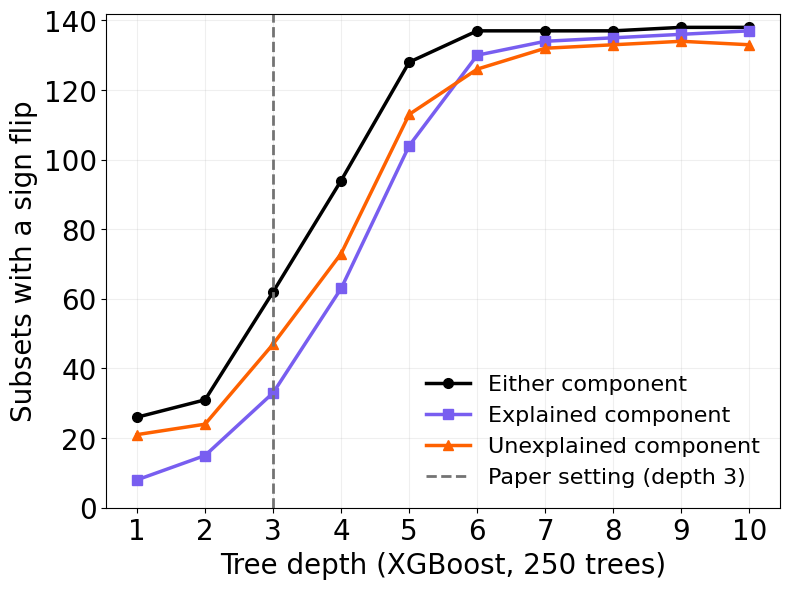

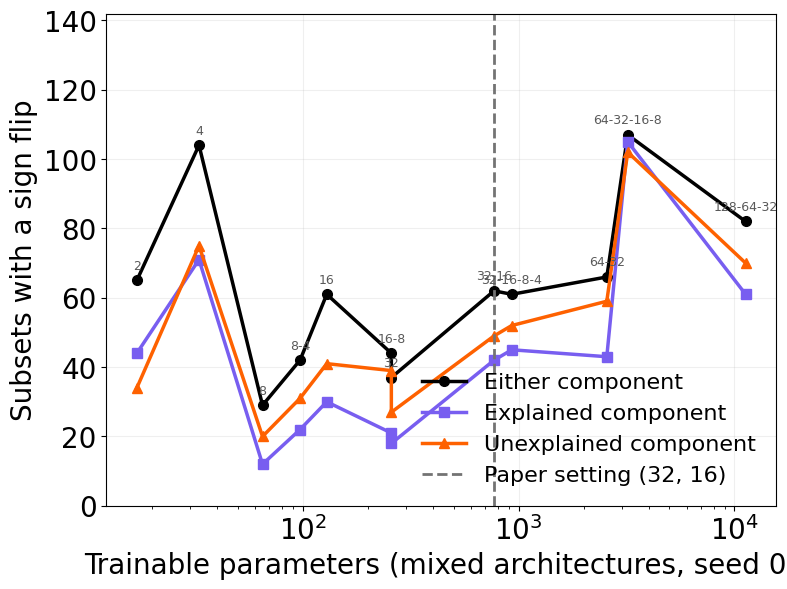

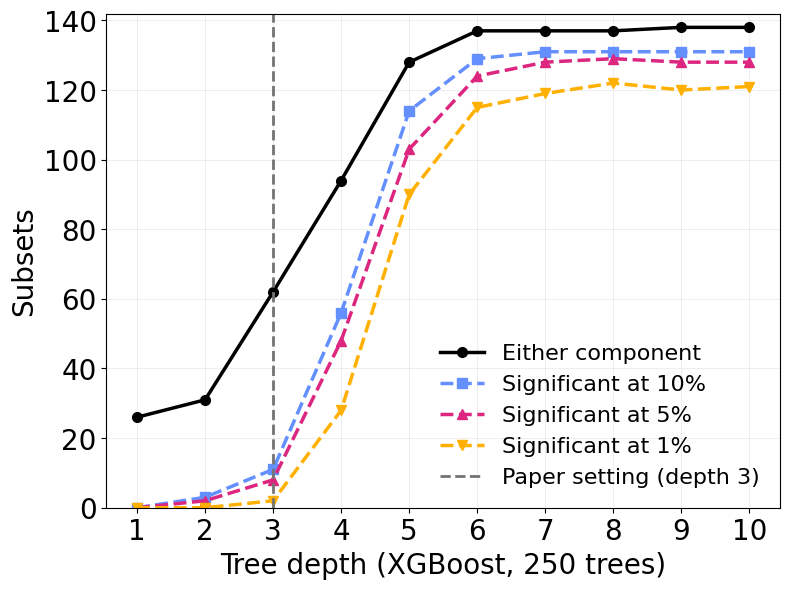

In [7]:
# --- figure style of the paper (Real-data example/icu_analysis.ipynb, plot_hr_quartile2_lines):
#     8 x 6 in, size-20 labels/ticks/legend, frameless legend, faint grid, 2.5-pt lines, PDF at 300 dpi.
#     Component colours are those of Sections/Figures/prob_unexplained.pdf (explained #785EF0, unexplained #FE6100).
FS = 20
COL_EITHER, COL_EXPL, COL_UNEXPL, COL_PAPER = "black", "#785EF0", "#FE6100", "0.45"
SERIES = [("total_flips", "Either component", COL_EITHER, "o"),
          ("explained_flips", "Explained component", COL_EXPL, "s"),
          ("unexplained_flips", "Unexplained component", COL_UNEXPL, "^")]

def paper_axes(ax, xlabel, ylabel="Subsets with a sign flip", logx=False, legend_loc="lower right"):
    ax.set_xlabel(xlabel, fontsize=FS); ax.set_ylabel(ylabel, fontsize=FS)
    ax.set_ylim(0, N * 1.02)
    if logx: ax.set_xscale("log")
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis="both", which="major", labelsize=FS)
    ax.legend(fontsize=FS - 4, loc=legend_loc, frameon=False)

def save_panel(fig, stem):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{stem}.pdf", format="pdf", bbox_inches="tight", dpi=300)
    fig.savefig(FIG_DIR / f"{stem}.png", format="png", bbox_inches="tight", dpi=150)
    # variant without the y-axis label, for the paper's multi-panel figure (one shared y label)
    ylab = fig.axes[0].get_ylabel(); fig.axes[0].set_ylabel("")
    fig.savefig(FIG_DIR / f"{stem}_noylabel.pdf", format="pdf", bbox_inches="tight", dpi=300)
    fig.axes[0].set_ylabel(ylab)

def flips_panel(summary, knob, xlabel, paper_x, paper_label, stem, logx=False, legend_loc="lower right", xticks=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    for col, lab, c, m in SERIES:
        ax.plot(summary[knob], summary[col], color=c, linewidth=2.5, marker=m, markersize=7, label=lab)
    ax.axvline(paper_x, color=COL_PAPER, linestyle="--", linewidth=2, label=paper_label)
    paper_axes(ax, xlabel, logx=logx, legend_loc=legend_loc)
    if xticks is not None: ax.set_xticks(xticks)
    save_panel(fig, stem); plt.show()

flips_panel(xgb_summary, "max_depth", "Tree depth (XGBoost, 250 trees)", PAPER_XGB_DEPTH, "Paper setting (depth 3)",
            "complexity_xgb_depth", xticks=XGB_DEPTHS)

# exploratory mixed architectures (§4): one seed, kept for the record
fig, ax = plt.subplots(figsize=(8, 6))
for col, lab, c, m in SERIES:
    ax.plot(nn_summary["n_params"], nn_summary[col], color=c, linewidth=2.5, marker=m, markersize=7, label=lab)
pp = nn_summary.loc[nn_summary["arch"] == paper_lbl, "n_params"].iloc[0]
ax.axvline(pp, color=COL_PAPER, linestyle="--", linewidth=2, label="Paper setting (32, 16)")
for _, r in nn_summary.iterrows():
    ax.annotate(r["arch"], (r["n_params"], r["total_flips"]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, color="0.35")
paper_axes(ax, "Trainable parameters (mixed architectures, seed 0)", logx=True)
save_panel(fig, "complexity_nn_mixed"); plt.show()

if xgb_boot is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(xgb_summary["max_depth"], xgb_summary["total_flips"], color=COL_EITHER, linewidth=2.5, marker="o", markersize=7, label="Either component")
    for col, lab, c, m in [("total_sig_10", "Significant at 10%", "#648FFF", "s"), ("total_sig_05", "Significant at 5%", "#DC267F", "^"), ("total_sig_01", "Significant at 1%", "#FFB000", "v")]:
        ax.plot(xgb_boot["max_depth"], xgb_boot[col], color=c, linewidth=2.5, linestyle="--", marker=m, markersize=7, label=lab)
    ax.axvline(PAPER_XGB_DEPTH, color=COL_PAPER, linestyle="--", linewidth=2, label="Paper setting (depth 3)")
    paper_axes(ax, "Tree depth (XGBoost, 250 trees)", ylabel="Subsets")
    ax.set_xticks(XGB_DEPTHS)
    save_panel(fig, "complexity_xgb_depth_significance"); plt.show()


## 6. Findings from §3–§4

**XGBoost depth is a clean complexity knob.** Flips rise monotonically with `max_depth`
(26 → 31 → 62 at the paper's depth 3 → 94 → 128 → 137, saturating by depth 6), and the earlier
B = 1000 bootstrap shows the *significant* flips rising the same way. Depth 3 reproduces
Table 1 exactly.

**Mixed architectures are not a clean knob.** `(32, 16)` reproduces Table 1 exactly, but the
curve over the twelve mixed architectures is non-monotone: at a single seed, with 6 inputs and
1–3k rows per group, flips reflect how the two group-specific networks happened to converge as
much as capacity. §8–§9 address this with nested architectures and repeated seeds.

## 7. XGBoost: number of trees

Depth fixed at the paper's 3; `n_estimators` from 10 to 10,000. 250 is the paper's setting.

In [8]:
xgbt_df = cached_sweep("xgb_trees_sweep_rows.csv", [(f"trees {n}", n) for n in XGB_TREES], lambda n: build_xgb(n_estimators=n), "xgb")
xgbt_df["n_estimators"] = xgbt_df["setting"].str.split().str[-1].astype(int)
xgbt_df.to_csv(OUT_DIR / "xgb_trees_sweep_rows.csv", index=False)
xgbt_summary = summarize(xgbt_df, "n_estimators")
xgbt_summary.to_csv(OUT_DIR / "xgb_trees_sweep_summary.csv", index=False)
paper = xgbt_summary[xgbt_summary["n_estimators"] == PAPER_XGB_TREES].iloc[0]
print(f"\nPaper setting ({PAPER_XGB_TREES} trees): total={int(paper.total_flips)} explained={int(paper.explained_flips)} "
      f"unexplained={int(paper.unexplained_flips)}   | Table 1 / Tables 3-4: 62 / 33 / 47")
xgbt_summary

  loaded cached xgb_trees_sweep_rows.csv (1390 rows, 10 settings); 0 new setting(s) to fit; set OBD_RECOMPUTE=1 to refit all

Paper setting (250 trees): total=62 explained=33 unexplained=47   | Table 1 / Tables 3-4: 62 / 33 / 47


,n_estimators,total_flips,explained_flips,unexplained_flips,n_subsets,n_errors
0,10,27,14,16,139,0
1,25,23,9,17,139,0
2,50,26,10,19,139,0
3,100,31,12,22,139,0
4,250,62,33,47,139,0
5,500,91,61,72,139,0
6,1000,122,98,104,139,0
7,2000,133,126,123,139,0
8,4000,135,131,125,139,0
9,10000,137,134,127,139,0


## 8. Neural net: width at fixed depth 3, three seeds

Architectures `(w, w, w)` for w = 8 … 768 — each strictly wider than the last, everything else
at the paper's values. 768 gives 1.19 M parameters. Every width is run at three initialization
seeds (0 = the paper's); the spread across seeds is the optimization noise.

In [9]:
width_settings = [(f"w={w} s={s}", (w, s)) for w in NN_WIDTHS for s in NN_SEEDS]
nnw_df = cached_sweep("nn_width_sweep_rows.csv", width_settings, lambda ws: build_nn(hidden=(ws[0],) * 3, seed=ws[1]), "nn-width")
nnw_df["width"] = nnw_df["setting"].str.extract(r"w=(\d+)").astype(int)
nnw_df["seed"]  = nnw_df["setting"].str.extract(r"s=(\d+)").astype(int)
nnw_df["n_params"] = nnw_df["width"].map(lambda w: nn_n_params((w,) * 3))
nnw_df.to_csv(OUT_DIR / "nn_width_sweep_rows.csv", index=False)
nnw_per_seed, nnw_summary = summarize_seeds(nnw_df, "width")
nnw_summary["n_params"] = nnw_summary["width"].map(lambda w: nn_n_params((w,) * 3))
nnw_per_seed["n_params"] = nnw_per_seed["width"].map(lambda w: nn_n_params((w,) * 3))
nnw_per_seed.to_csv(OUT_DIR / "nn_width_sweep_per_seed.csv", index=False)
nnw_summary.to_csv(OUT_DIR / "nn_width_sweep_summary.csv", index=False)
nnw_summary

  loaded cached nn_width_sweep_rows.csv (3336 rows, 24 settings); 0 new setting(s) to fit; set OBD_RECOMPUTE=1 to refit all


,width,total_mean,total_min,total_max,explained_mean,unexplained_mean,n_errors,n_params
0,8,45.666667,41,54,23.000000,34.666667,0,209
1,16,54.666667,50,62,37.000000,41.000000,0,673
2,32,69.666667,61,76,50.000000,57.333333,0,2369
3,64,89.000000,85,96,68.666667,82.666667,0,8833
4,128,96.666667,89,105,76.666667,88.333333,0,34049
5,256,94.333333,87,99,74.666667,84.000000,0,133633
6,512,85.000000,81,90,67.333333,74.666667,0,529409
7,768,86.333333,80,96,70.666667,74.333333,0,1187329


## 9. Neural net: depth at fixed width 32, three seeds

Architectures `(32,) * d` for d = 1 … 16 — each strictly deeper than the last.

In [10]:
depth_settings = [(f"d={d} s={s}", (d, s)) for d in NN_DEPTHS for s in NN_SEEDS]
nnd_df = cached_sweep("nn_depth_sweep_rows.csv", depth_settings, lambda ds: build_nn(hidden=(32,) * ds[0], seed=ds[1]), "nn-depth")
nnd_df["depth"] = nnd_df["setting"].str.extract(r"d=(\d+)").astype(int)
nnd_df["seed"]  = nnd_df["setting"].str.extract(r"s=(\d+)").astype(int)
nnd_df["n_params"] = nnd_df["depth"].map(lambda d: nn_n_params((32,) * d))
nnd_df.to_csv(OUT_DIR / "nn_depth_sweep_rows.csv", index=False)
nnd_per_seed, nnd_summary = summarize_seeds(nnd_df, "depth")
nnd_summary["n_params"] = nnd_summary["depth"].map(lambda d: nn_n_params((32,) * d))
nnd_per_seed["n_params"] = nnd_per_seed["depth"].map(lambda d: nn_n_params((32,) * d))
nnd_per_seed.to_csv(OUT_DIR / "nn_depth_sweep_per_seed.csv", index=False)
nnd_summary.to_csv(OUT_DIR / "nn_depth_sweep_summary.csv", index=False)
nnd_summary

  loaded cached nn_depth_sweep_rows.csv (3336 rows, 24 settings); 0 new setting(s) to fit; set OBD_RECOMPUTE=1 to refit all


,depth,total_mean,total_min,total_max,explained_mean,unexplained_mean,n_errors,n_params
0,1,32.666667,30,37,12.333333,26.000000,0,257
1,2,57.000000,49,65,33.666667,45.666667,0,1313
2,3,69.666667,61,76,50.000000,57.333333,0,2369
3,4,75.666667,69,88,55.333333,63.666667,0,3425
4,6,70.666667,61,76,54.000000,59.333333,0,5537
5,8,69.000000,62,74,52.333333,52.333333,0,7649
6,12,69.666667,57,76,53.000000,59.666667,0,11873
7,16,65.333333,57,78,51.000000,52.666667,0,16097


## 10. Plots for §7–§9 (paper figure style)

Solid line: mean over seeds; band: min–max over seeds. Dashed line: the paper's `(32, 16)` model (Table 1). Saved as `Figures/complexity_xgb_trees.pdf`, `complexity_nn_width.pdf`, `complexity_nn_depth.pdf`.

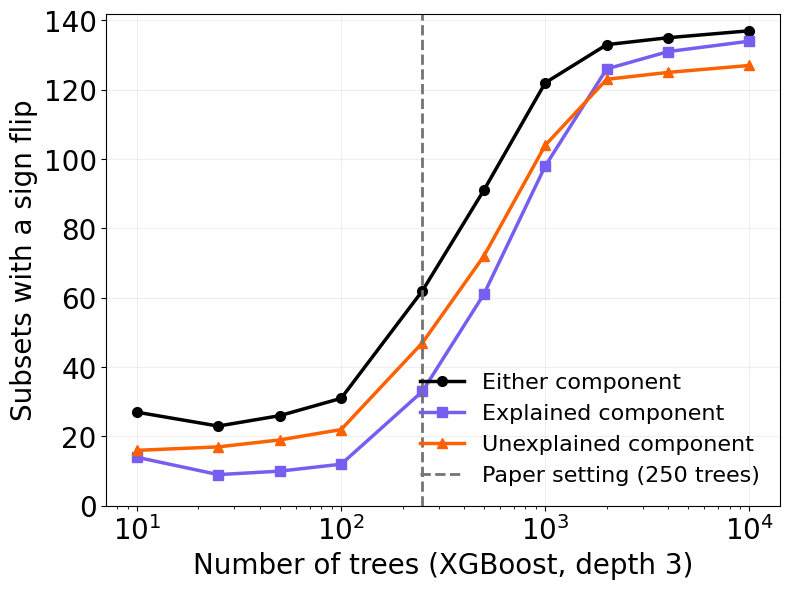

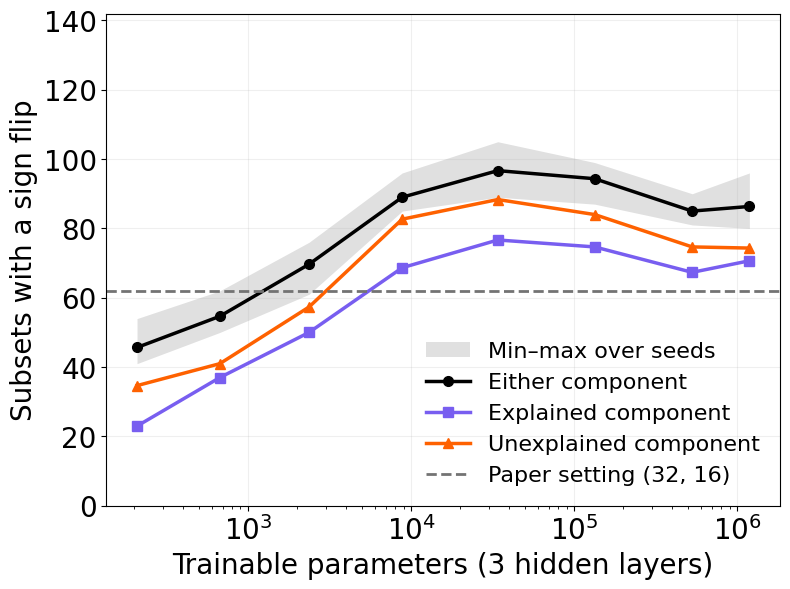

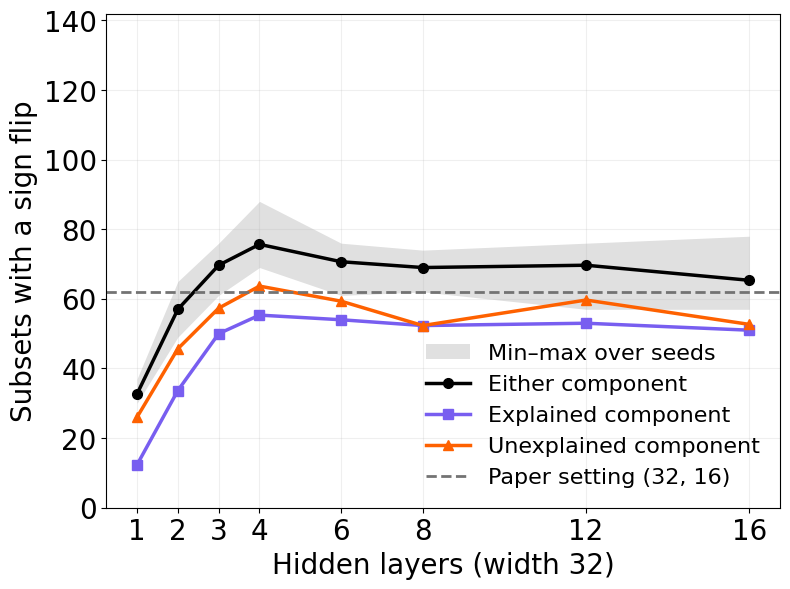

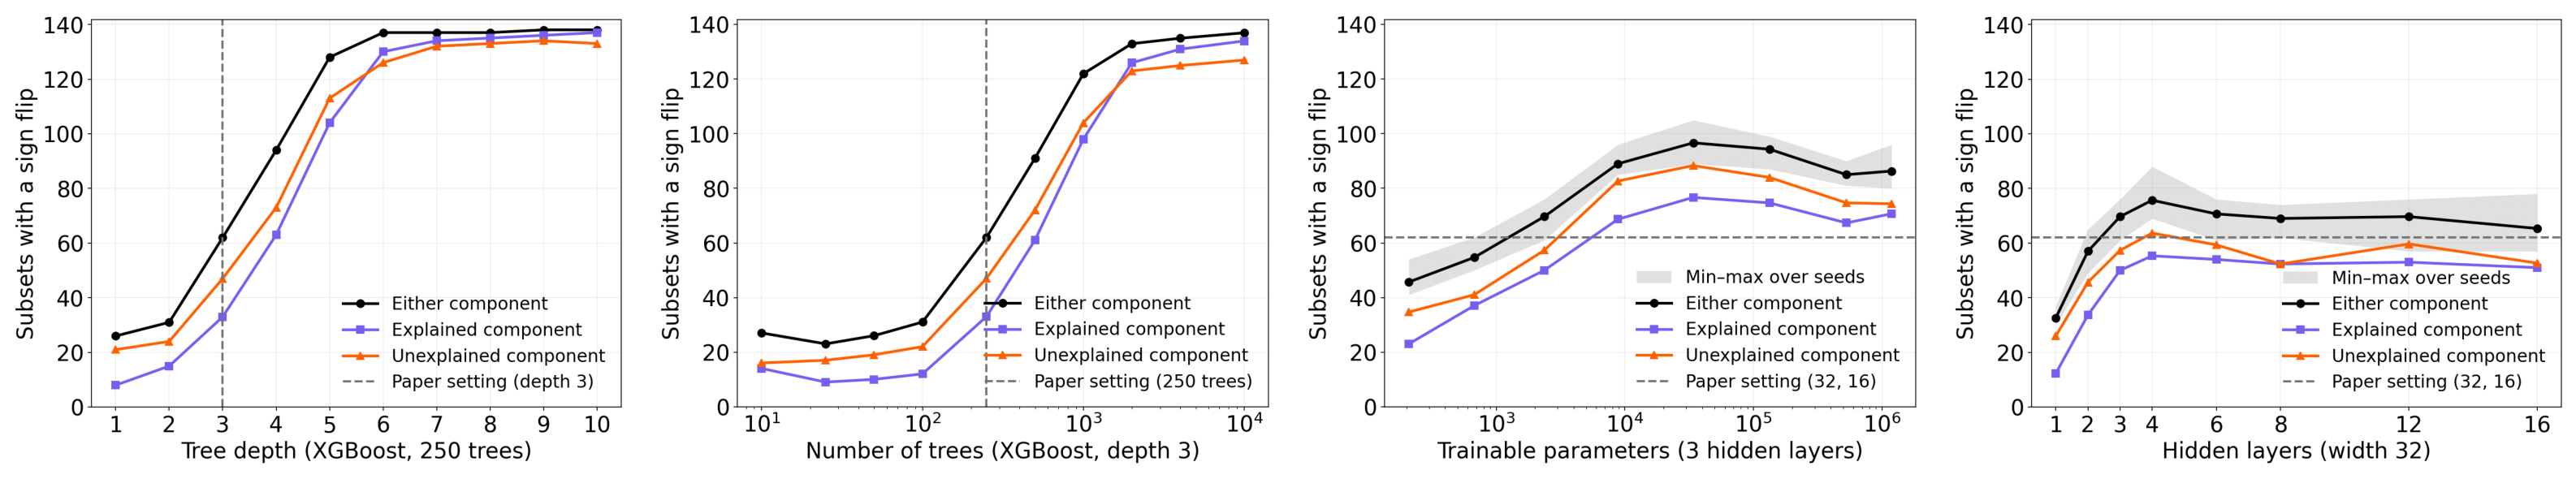

In [11]:
def seed_panel(per_seed, agg, knob, xlabel, stem, logx=False, legend_loc="lower right", xticks=None):
    """Mean over seeds (lines), min–max over seeds (band); dashed line = the paper's (32, 16) net."""
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.fill_between(agg[knob], agg["total_min"], agg["total_max"], color=COL_EITHER, alpha=0.12, linewidth=0, label="Min–max over seeds")
    ax.plot(agg[knob], agg["total_mean"], color=COL_EITHER, linewidth=2.5, marker="o", markersize=7, label="Either component")
    ax.plot(agg[knob], agg["explained_mean"], color=COL_EXPL, linewidth=2.5, marker="s", markersize=7, label="Explained component")
    ax.plot(agg[knob], agg["unexplained_mean"], color=COL_UNEXPL, linewidth=2.5, marker="^", markersize=7, label="Unexplained component")
    ax.axhline(PAPER_NN_FLIPS, color=COL_PAPER, linestyle="--", linewidth=2, label="Paper setting (32, 16)")
    paper_axes(ax, xlabel, logx=logx, legend_loc=legend_loc)
    if xticks is not None: ax.set_xticks(xticks)
    save_panel(fig, stem); plt.show()

flips_panel(xgbt_summary, "n_estimators", "Number of trees (XGBoost, depth 3)", PAPER_XGB_TREES, "Paper setting (250 trees)",
            "complexity_xgb_trees", logx=True)
seed_panel(nnw_per_seed, nnw_summary, "n_params", "Trainable parameters (3 hidden layers)", "complexity_nn_width", logx=True)
seed_panel(nnd_per_seed, nnd_summary, "depth", "Hidden layers (width 32)", "complexity_nn_depth", xticks=NN_DEPTHS)

# side-by-side preview of the four main panels (PNG only; the paper uses the individual PDFs)
import matplotlib.image as mpimg
fig, axes = plt.subplots(1, 4, figsize=(32, 6))
for ax, stem in zip(axes, ["complexity_xgb_depth", "complexity_xgb_trees", "complexity_nn_width", "complexity_nn_depth"]):
    ax.imshow(mpimg.imread(FIG_DIR / f"{stem}.png")); ax.axis("off")
fig.tight_layout(); fig.savefig(FIG_DIR / "complexity_sweep_nested.png", dpi=100, bbox_inches="tight"); plt.show()


## 11. Side-by-side summary

In [12]:
side = pd.concat([
    xgb_summary.assign(family="XGBoost depth", knob=lambda d: "depth " + d["max_depth"].astype(str))[["family", "knob", "total_flips", "explained_flips", "unexplained_flips", "n_errors"]],
    xgbt_summary.assign(family="XGBoost trees", knob=lambda d: d["n_estimators"].astype(str) + " trees")[["family", "knob", "total_flips", "explained_flips", "unexplained_flips", "n_errors"]],
    nn_summary.assign(family="NN mixed (seed 0)", knob=lambda d: d["arch"] + " (" + d["n_params"].astype(str) + " params)")[["family", "knob", "total_flips", "explained_flips", "unexplained_flips", "n_errors"]],
    nnw_summary.assign(family="NN width, depth 3 (mean of 3 seeds)", knob=lambda d: "w=" + d["width"].astype(str) + " (" + d["n_params"].astype(str) + " params)",
                       total_flips=lambda d: d["total_mean"].round(1), explained_flips=lambda d: d["explained_mean"].round(1), unexplained_flips=lambda d: d["unexplained_mean"].round(1))[["family", "knob", "total_flips", "explained_flips", "unexplained_flips", "n_errors"]],
    nnd_summary.assign(family="NN depth, width 32 (mean of 3 seeds)", knob=lambda d: "d=" + d["depth"].astype(str) + " (" + d["n_params"].astype(str) + " params)",
                       total_flips=lambda d: d["total_mean"].round(1), explained_flips=lambda d: d["explained_mean"].round(1), unexplained_flips=lambda d: d["unexplained_mean"].round(1))[["family", "knob", "total_flips", "explained_flips", "unexplained_flips", "n_errors"]],
], ignore_index=True)
side.to_csv(OUT_DIR / "complexity_sweep_summary.csv", index=False)
side

,family,knob,total_flips,explained_flips,unexplained_flips,n_errors
0,XGBoost depth,depth 1,26.0,8.0,21.0,0
1,XGBoost depth,depth 2,31.0,15.0,24.0,0
2,XGBoost depth,depth 3,62.0,33.0,47.0,0
3,XGBoost depth,depth 4,94.0,63.0,73.0,0
4,XGBoost depth,depth 5,128.0,104.0,113.0,0
5,XGBoost depth,depth 6,137.0,130.0,126.0,0
6,XGBoost depth,depth 7,137.0,134.0,132.0,0
7,XGBoost depth,depth 8,137.0,135.0,133.0,0
8,XGBoost depth,depth 9,138.0,136.0,134.0,0
9,XGBoost depth,depth 10,138.0,137.0,133.0,0
